# Entrenamiento Forward-Forward de una BNN desde cero en Python

## Objetivo
Implementar manualmente el algoritmo Forward-Forward para entrenar una red neuronal binaria (BNN) capaz de clasificar imágenes de dígitos escritos a mano.

## Metas de aprendizaje
1. Entender el funcionamiento básico de una red neuronal.
2. Comprender qué es una red neuronal binaria.
3. Implementar el entrenamiento Forward-Forward desde cero.
4. Visualizar en tiempo real el comportamiento del entrenamiento.
5. Analizar cómo afecta la reducción de resolución de las imágenes al desempeño del modelo.

## Dataset
Se utilizarán los archivos:
- `train.csv`
- `test.csv`

## Alcance
- Dataset: Digit Recognizer (MNIST en formato CSV).
- Implementación manual del algoritmo FF.
- Clasificación supervisada con etiquetas incrustadas en la entrada.
- Comparación entre distintas resoluciones de imagen.

## Importación de librerías

En esta sección se importan únicamente librerías de apoyo general para:
- manejo numérico,
- lectura de datos,
- visualización,
- división del dataset,
- métricas.

In [1]:
# Librerías para operaciones numéricas y manejo de tablas.
import numpy as np
import pandas as pd

# Librería para gráficos y visualización de resultados.
import matplotlib.pyplot as plt

# Librería para medir tiempos de ejecución.
import time

# Utilidad de Jupyter para actualizar gráficos en vivo.
from IPython.display import clear_output

# Herramientas auxiliares para dividir datos y calcular métricas.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Configuración general

En esta sección se definen las constantes del experimento, como la semilla aleatoria, el tamaño de imagen, la cantidad de clases, el número de épocas y la arquitectura base de la red.

In [2]:
# Fija la semilla para que los resultados sean reproducibles.
SEED = 42
np.random.seed(SEED)

# Define la cantidad total de clases del problema MNIST (0 - 9).
NUM_CLASSES = 10

# Define la resolución original de las imágenes.
ORIGINAL_IMG_SIZE = 28

# Define la arquitectura base del MLP binario.
INPUT_LABEL_DIM = NUM_CLASSES

# Controla cada cuántas épocas se actualiza la visualización.
PLOT_EVERY = 1

In [3]:
# Configuración recomendada para esta versión con ReLU.
IMG_SIZE = 28
HIDDEN_DIMS = [512, 256]

EPOCHS = 50
BATCH_SIZE = 256
LEARNING_RATE = 0.005

# Este valor puede requerir ajuste.
THRESHOLD = 7.0

# Nueva escala para la etiqueta.
LABEL_SCALE = 4.0

# Límite para pesos latentes.
WEIGHT_CLIP = 2.5

## Idea general del algoritmo Forward-Forward

A diferencia del entrenamiento clásico por backpropagation, el algoritmo Forward-Forward entrena la red comparando:

- **ejemplos positivos**: imagen + etiqueta correcta
- **ejemplos negativos**: imagen + etiqueta incorrecta

Cada capa busca:
- producir **alta goodness** para ejemplos positivos;
- producir **baja goodness** para ejemplos negativos.

La clasificación final se realiza probando una imagen con todas las etiquetas posibles y eligiendo aquella que produzca la mayor goodness total acumulada.

## Carga del dataset

Se utilizarán dos archivos:
- `train.csv`: contiene imágenes y etiquetas.
- `test.csv`: contiene imágenes sin etiquetas.

Formato esperado:
- `train.csv`:
  - una columna `label`
  - 784 columnas de píxeles
- `test.csv`:
  - 784 columnas de píxeles

In [4]:
def load_train_csv(csv_path):
    """
    Carga el archivo train.csv del dataset de Kaggle.

    Parameters
    ----------
    csv_path : str
        Ruta del archivo train.csv.

    Returns
    -------
    X : np.ndarray
        Imágenes con forma (n_samples, 28, 28).
    y : np.ndarray
        Etiquetas con forma (n_samples,).
    """
    # Leer el archivo CSV completo.
    df = pd.read_csv(csv_path)

    # Extraer las etiquetas.
    y = df["label"].values.astype(np.int64)

    # Extraer los píxeles de las imágenes.
    X = df.drop(columns=["label"]).values.astype(np.float32)

    # Reorganizar cada fila en una imagen 28x28.
    X = X.reshape(-1, ORIGINAL_IMG_SIZE, ORIGINAL_IMG_SIZE)

    return X, y

In [5]:
def load_test_csv(csv_path):
    """
    Carga el archivo test.csv del dataset de Kaggle.

    Parameters
    ----------
    csv_path : str
        Ruta del archivo test.csv.

    Returns
    -------
    X : np.ndarray
        Imágenes con forma (n_samples, 28, 28).
    """
    # Leer el archivo CSV completo.
    df = pd.read_csv(csv_path)

    # Convertir los datos a arreglo flotante.
    X = df.values.astype(np.float32)

    # Reorganizar cada fila en una imagen 28x28.
    X = X.reshape(-1, ORIGINAL_IMG_SIZE, ORIGINAL_IMG_SIZE)

    return X

In [6]:
# Ajusta esta ruta según la ubicación del archivo CSV.
csv_path = "D:/Proyectos/digit-recognizer/train.csv"

# Rutas de los archivos del dataset.
TRAIN_CSV_PATH = "D:/Proyectos/digit-recognizer/train.csv"
TEST_CSV_PATH = "D:/Proyectos/digit-recognizer/test.csv"

# Cargar datos de entrenamiento con etiquetas.
X_full, y_full = load_train_csv(TRAIN_CSV_PATH)

# Cargar datos de prueba sin etiquetas.
X_kaggle_test = load_test_csv(TEST_CSV_PATH)

# Mostrar dimensiones para verificación rápida.
print("X_full:", X_full.shape)
print("y_full:", y_full.shape)
print("X_kaggle_test:", X_kaggle_test.shape)
print("Clases disponibles:", np.unique(y_full))

X_full: (42000, 28, 28)
y_full: (42000,)
X_kaggle_test: (28000, 28, 28)
Clases disponibles: [0 1 2 3 4 5 6 7 8 9]


## Visualización inicial

Antes de entrenar el modelo, se inspeccionan algunas imágenes del conjunto etiquetado para confirmar:
- que las imágenes se cargaron correctamente;
- que las etiquetas son coherentes.

In [7]:
def show_samples(X, y, num_samples=10):
    """
    Muestra ejemplos aleatorios del dataset etiquetado.

    Parameters
    ----------
    X : np.ndarray
        Imágenes con forma (n_samples, height, width).
    y : np.ndarray
        Etiquetas asociadas a las imágenes.
    num_samples : int, optional
        Cantidad de ejemplos a mostrar.
    """
    # Seleccionar índices aleatorios sin repetición.
    indices = np.random.choice(len(X), num_samples, replace=False)

    # Crear la figura.
    plt.figure(figsize=(14, 3))

    # Dibujar cada imagen seleccionada.
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X[idx])
        plt.title(f"y = {y[idx]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

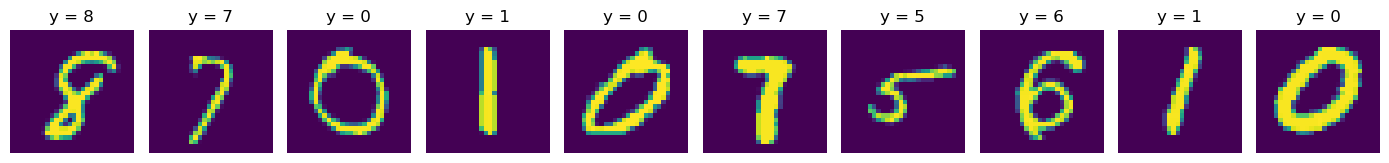

In [8]:
# Mostrar algunas muestras del conjunto de entrenamiento.
show_samples(X_full, y_full, num_samples=10)

## División interna del conjunto etiquetado

Como `test.csv` no trae etiquetas, se hará una división interna sobre `train.csv` para construir:

- entrenamiento,
- validación,
- prueba interna con etiquetas.

Esto permitirá evaluar el modelo de forma supervisada.

In [9]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, seed=SEED):
    """
    Divide el dataset etiquetado en entrenamiento, validación y prueba.

    Parameters
    ----------
    X : np.ndarray
        Imágenes.
    y : np.ndarray
        Etiquetas.
    test_size : float, optional
        Proporción destinada al conjunto de prueba.
    val_size : float, optional
        Proporción destinada al conjunto de validación.
    seed : int, optional
        Semilla aleatoria.

    Returns
    -------
    X_train : np.ndarray
        Imágenes de entrenamiento.
    y_train : np.ndarray
        Etiquetas de entrenamiento.
    X_val : np.ndarray
        Imágenes de validación.
    y_val : np.ndarray
        Etiquetas de validación.
    X_test : np.ndarray
        Imágenes de prueba interna.
    y_test : np.ndarray
        Etiquetas de prueba interna.
    """
    # Primera división: separar conjunto de prueba interna.
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y
    )

    # Ajustar proporción relativa para validación.
    val_relative_size = val_size / (1 - test_size)

    # Segunda división: separar entrenamiento y validación.
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_relative_size,
        random_state=seed,
        stratify=y_train_full
    )

    return X_train, y_train, X_val, y_val, X_test, y_test

In [10]:
# Dividir el conjunto etiquetado.
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(
    X_full,
    y_full
)

# Mostrar dimensiones resultantes.
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (29400, 28, 28) (29400,)
Val:   (6300, 28, 28) (6300,)
Test:  (6300, 28, 28) (6300,)


## Preprocesamiento

En esta etapa se aplican transformaciones sobre las imágenes:

1. normalización;
2. reducción opcional de resolución;
3. binarización;
4. aplanado a vector 1D.

Este flujo es importante para una BNN, ya que la representación final será más simple y más cercana a una implementación digital.

In [11]:
def normalize_images(X):
    """
    Normaliza los valores de intensidad al rango [0, 1].

    Parameters
    ----------
    X : np.ndarray
        Imágenes con intensidades originales.

    Returns
    -------
    np.ndarray
        Imágenes normalizadas.
    """
    return X / 255.0

In [12]:
def resize_images_average_pooling(X, new_size):
    """
    Reduce la resolución mediante promedio por bloques.

    Esta función supone que el tamaño original es divisible
    exactamente entre el nuevo tamaño.

    Parameters
    ----------
    X : np.ndarray
        Imágenes con forma (n_samples, old_size, old_size).
    new_size : int
        Nuevo tamaño deseado.

    Returns
    -------
    np.ndarray
        Imágenes redimensionadas.
    """
    # Obtener el tamaño original.
    old_size = X.shape[1]

    # Verificar que exista divisibilidad exacta.
    if old_size % new_size != 0:
        raise ValueError(
            "El nuevo tamaño debe dividir exactamente "
            "el tamaño original."
        )

    # Calcular el factor de reducción.
    factor = old_size // new_size

    # Reagrupar la imagen en bloques.
    X_reshaped = X.reshape(-1, new_size, factor, new_size, factor)

    # Promediar cada bloque.
    X_resized = X_reshaped.mean(axis=(2, 4))

    return X_resized

In [13]:
def binarize_images(X, threshold=0.5):
    """
    Convierte la imagen a valores binarios 0 y 1.

    Parameters
    ----------
    X : np.ndarray
        Imágenes normalizadas.
    threshold : float, optional
        Umbral de binarización.

    Returns
    -------
    np.ndarray
        Imágenes binarizadas.
    """
    return np.where(X >= threshold, 1.0, 0.0)

In [14]:
def flatten_images(X):
    """
    Aplana imágenes 2D a vectores 1D.

    Parameters
    ----------
    X : np.ndarray
        Imágenes con forma (n_samples, height, width).

    Returns
    -------
    np.ndarray
        Vectores con forma (n_samples, height * width).
    """
    return X.reshape(X.shape[0], -1)

In [15]:
def preprocess_images(X, img_size=28, normalize=True, binarize_input=False,
                      bin_threshold=0.5):
    """
    Aplica el flujo de preprocesamiento a las imágenes.

    Cambios realizados
    ------------------
    1. La binarización de entrada ahora es opcional.
    2. Por defecto se conserva la intensidad continua en [0, 1].
    3. Esto permite preservar más información visual que una imagen 0/1.

    Parameters
    ----------
    X : np.ndarray
        Imágenes originales.
    img_size : int, optional
        Resolución de salida deseada.
    normalize : bool, optional
        Si es True, normaliza los valores a [0, 1].
    binarize_input : bool, optional
        Si es True, aplica binarización dura a la imagen.
    bin_threshold : float, optional
        Umbral de binarización si binarize_input es True.

    Returns
    -------
    np.ndarray
        Imágenes procesadas y aplanadas.
    """
    X_proc = X.astype(np.float32)

    # Cambio: conservar intensidades continuas ayuda bastante al entrenamiento.
    if normalize:
        X_proc = X_proc / 255.0

    # Reducir resolución si se solicita.
    if img_size != ORIGINAL_IMG_SIZE:
        X_proc = resize_images_average_pooling(X_proc, img_size)

    # Cambio: la binarización ahora es opcional.
    if binarize_input:
        X_proc = np.where(X_proc >= bin_threshold, 1.0, 0.0)

    # Aplanar cada imagen a un vector 1D.
    X_proc = X_proc.reshape(X_proc.shape[0], -1)

    return X_proc.astype(np.float32)

In [16]:
# Aplicar preprocesamiento a cada subconjunto.
X_train_proc = preprocess_images(
    X_train,
    img_size=IMG_SIZE,
    normalize=True,
    binarize_input=False
)

X_val_proc = preprocess_images(
    X_val,
    img_size=IMG_SIZE,
    normalize=True,
    binarize_input=False
)

X_test_proc = preprocess_images(
    X_test,
    img_size=IMG_SIZE,
    normalize=True,
    binarize_input=False
)

# Preprocesar también el test de Kaggle sin etiquetas.
X_kaggle_test_proc = preprocess_images(
    X_kaggle_test,
    img_size=IMG_SIZE,
    normalize=True,
    binarize_input=False
)

# Mostrar forma del conjunto preprocesado.
print("X_train_proc:", X_train_proc.shape)
print("X_kaggle_test_proc:", X_kaggle_test_proc.shape)

X_train_proc: (29400, 784)
X_kaggle_test_proc: (28000, 784)


## Comparación visual del preprocesamiento

Esta sección permite observar:
- la imagen original;
- la imagen binarizada y redimensionada.

Esto ayuda a entender qué información se conserva y cuál se pierde.

In [17]:
def show_preprocessing_examples(X_original, y, img_size=28, num_samples=5):
    """
    Muestra ejemplos antes y después del preprocesamiento.

    Parameters
    ----------
    X_original : np.ndarray
        Imágenes originales.
    y : np.ndarray
        Etiquetas.
    img_size : int, optional
        Resolución de salida.
    num_samples : int, optional
        Cantidad de ejemplos a mostrar.
    """
    # Elegir ejemplos aleatorios.
    indices = np.random.choice(len(X_original), num_samples, replace=False)

    # Preprocesar solo las imágenes seleccionadas.
    X_proc = preprocess_images(X_original[indices], img_size=img_size)

    # Crear figura comparativa.
    plt.figure(figsize=(10, 4))

    for i, idx in enumerate(indices):
        # Mostrar imagen original.
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(X_original[idx], cmap="gray")
        plt.title(f"Orig y = {y[idx]}")
        plt.axis("off")

        # Mostrar imagen procesada.
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(X_proc[i].reshape(img_size, img_size), cmap="gray")
        plt.title(f"Proc {img_size}x{img_size}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

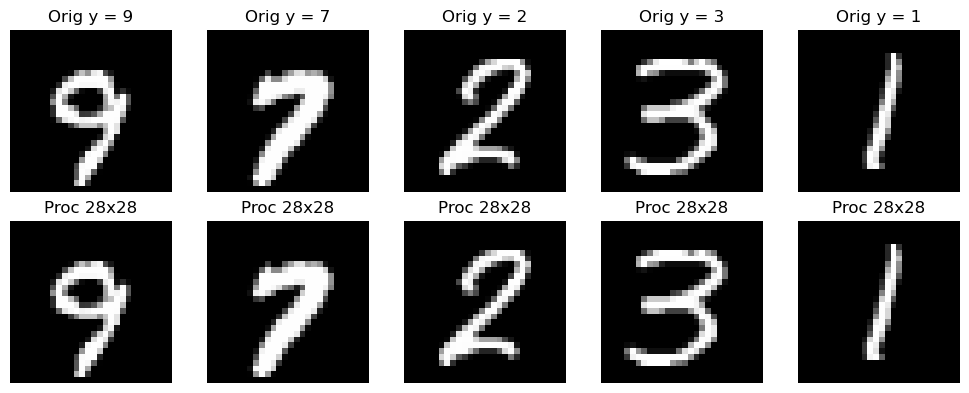

In [18]:
# Mostrar comparación visual de algunas muestras.
show_preprocessing_examples(X_train, y_train, img_size=IMG_SIZE, num_samples=5)

## Manejo de etiquetas

En Forward-Forward supervisado, la etiqueta se incorpora a la entrada.  
Para eso necesitaremos:
- codificación one-hot;
- generación de etiquetas negativas;
- concatenación de la etiqueta al vector de imagen.

In [19]:
def one_hot_encode(y, num_classes=NUM_CLASSES):
    """
    Convierte etiquetas enteras a codificación one-hot.
    Pasa de un 3 a un [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

    Parameters
    ----------
    y : np.ndarray
        Etiquetas enteras.
    num_classes : int, optional
        Número de clases.

    Returns
    -------
    np.ndarray
        Matriz one-hot.
    """
    # Inicializar matriz en ceros.
    one_hot = np.zeros((len(y), num_classes), dtype=np.float32)

    # Asignar 1.0 en la posición correspondiente a cada clase.
    one_hot[np.arange(len(y)), y] = 1.0

    return one_hot

In [20]:
def create_negative_labels(y, num_classes=NUM_CLASSES):
    """
    Genera una etiqueta incorrecta para cada muestra.

    Parameters
    ----------
    y : np.ndarray
        Etiquetas correctas.
    num_classes : int, optional
        Número total de clases.

    Returns
    -------
    np.ndarray
        Etiquetas negativas incorrectas.
    """
    # Crear copia para almacenar resultados.
    y_neg = np.copy(y)

    # Para cada muestra, elegir una clase distinta a la correcta.
    for i in range(len(y)):
        candidates = list(range(num_classes))
        candidates.remove(y[i])
        y_neg[i] = np.random.choice(candidates)

    return y_neg

In [21]:
def overlay_label_on_input(X, y, num_classes=NUM_CLASSES, label_scale=2.0):
    """
    Concatena la etiqueta one-hot escalada al vector de entrada.

    Cambios realizados
    ------------------
    1. Se agregó `label_scale`.
    2. Esto permite darle más peso relativo a la etiqueta dentro de la entrada.
    3. Es útil porque, si la etiqueta es muy débil, la red puede ignorarla.

    Parameters
    ----------
    X : np.ndarray
        Vectores de imagen.
    y : np.ndarray
        Etiquetas enteras.
    num_classes : int, optional
        Número total de clases.
    label_scale : float, optional
        Escala aplicada al vector one-hot.

    Returns
    -------
    np.ndarray
        Entrada extendida con la etiqueta.
    """
    y_one_hot = one_hot_encode(y, num_classes=num_classes)
    y_one_hot = y_one_hot * label_scale

    return np.concatenate([X, y_one_hot], axis=1)

## BNN: pesos y activaciones binarias

En esta implementación:
- los pesos se almacenan en forma real latente;
- durante el forward se binarizan con signo;
- las activaciones también se binarizan.

In [22]:
def sign_binary(x):
    """
    Binariza un arreglo usando signo.

    Parameters
    ----------
    x : np.ndarray
        Arreglo de entrada.

    Returns
    -------
    np.ndarray
        Arreglo binario con valores -1 y 1.
    """
    return np.where(x >= 0, 1.0, -1.0).astype(np.float32)

In [23]:
def binarize_weights(W):
    """
    Binariza la matriz de pesos para el forward.

    Parameters
    ----------
    W : np.ndarray
        Matriz de pesos latentes.

    Returns
    -------
    np.ndarray
        Matriz binaria de pesos.
    """
    return sign_binary(W)

In [24]:
def binary_activation(x):
    """
    Aplica activación binaria al resultado lineal.

    Parameters
    ----------
    x : np.ndarray
        Activación previa a la no linealidad.

    Returns
    -------
    np.ndarray
        Activación binaria.
    """
    return sign_binary(x)

def relu_activation(x):
    """
    Aplica activación ReLU.

    Cambios realizados
    ------------------
    1. Se reemplazó la activación sign por ReLU.
    2. ReLU conserva información de magnitud positiva.
    3. Esto mejora la variación de la goodness y la estabilidad del entrenamiento.

    Parameters
    ----------
    x : np.ndarray
        Activación previa a la no linealidad.

    Returns
    -------
    np.ndarray
        Activación ReLU.
    """
    return np.maximum(x, 0.0).astype(np.float32)

## Inicialización de parámetros

La red será un MLP binario con capas ocultas densas.  
Cada capa tendrá:
- pesos latentes reales;
- bias real.

In [25]:
def init_layer(in_dim, out_dim, scale=0.1):
    """
    Inicializa una capa lineal.

    Parameters
    ----------
    in_dim : int
        Dimensión de entrada.
    out_dim : int
        Dimensión de salida.
    scale : float, optional
        Escala de inicialización aleatoria.

    Returns
    -------
    W : np.ndarray
        Matriz de pesos.
    b : np.ndarray
        Vector de bias.
    """
    # Inicializar pesos con distribución normal escalada.
    W = np.random.randn(in_dim, out_dim).astype(np.float32) * scale

    # Inicializar bias en cero.
    b = np.zeros((1, out_dim), dtype=np.float32)

    return W, b

In [26]:
def init_bnn_model(input_dim, hidden_dims):
    """
    Inicializa el modelo BNN multicapa.

    Parameters
    ----------
    input_dim : int
        Dimensión total de la entrada.
    hidden_dims : list[int]
        Lista con dimensiones de capas ocultas.

    Returns
    -------
    dict
        Diccionario con pesos y bias por capa.
    """
    # Construir lista de dimensiones de cada transición.
    dims = [input_dim] + hidden_dims

    # Estructura base del modelo.
    model = {"W": [], "b": []}

    # Crear cada capa.
    for i in range(len(dims) - 1):
        W, b = init_layer(dims[i], dims[i + 1])
        model["W"].append(W)
        model["b"].append(b)

    return model

In [27]:
# Calcular dimensión de entrada total: imagen + etiqueta.
input_dim = IMG_SIZE * IMG_SIZE + NUM_CLASSES

# Inicializar modelo.
model = init_bnn_model(input_dim=input_dim, hidden_dims=HIDDEN_DIMS)

# Mostrar forma de parámetros por capa.
for i, (W, b) in enumerate(zip(model["W"], model["b"])):
    print(f"Capa {i + 1}: W{W.shape}, b{b.shape}")

Capa 1: W(794, 512), b(1, 512)
Capa 2: W(512, 256), b(1, 256)


## Forward de la red

Cada capa realiza:
1. binarización de pesos;
2. producto lineal;
3. activación binaria;
4. cálculo de goodness.

In [28]:
def forward_layer(X, W, b):
    """
    Ejecuta el forward de una capa.

    Cambios realizados
    ------------------
    1. Se mantienen pesos binarios en el forward.
    2. Se usa ReLU como activación.
    3. Esto deja una BNN de pesos binarios, pero con activaciones más entrenables.

    Parameters
    ----------
    X : np.ndarray
        Entrada de la capa.
    W : np.ndarray
        Pesos latentes de la capa.
    b : np.ndarray
        Bias de la capa.

    Returns
    -------
    z : np.ndarray
        Salida lineal previa a la activación.
    h : np.ndarray
        Activación ReLU.
    """
    # Mantener pesos binarios en el forward.
    W_bin = binarize_weights(W)

    # Transformación lineal.
    z = X @ W_bin + b

    # Cambio: usar ReLU en lugar de sign.
    h = relu_activation(z)

    return z, h

In [29]:
def compute_goodness(h):
    """
    Calcula la goodness de una capa.

    Cambios realizados
    ------------------
    1. Ahora la goodness se calcula sobre activaciones ReLU.
    2. Como ReLU no colapsa a valores fijos como sign, la goodness sí varía.
    3. Esto hace que los scores entre clases sean comparables y útiles.

    Parameters
    ----------
    h : np.ndarray
        Activaciones de la capa.

    Returns
    -------
    np.ndarray
        Goodness por muestra.
    """
    return np.mean(h ** 2, axis=1)

In [30]:
def forward_network(X, model):
    """
    Ejecuta el forward completo de la red.

    Parameters
    ----------
    X : np.ndarray
        Entrada del modelo.
    model : dict
        Modelo con pesos y bias.

    Returns
    -------
    activations : list[np.ndarray]
        Activaciones por capa.
    goodness_list : list[np.ndarray]
        Goodness por capa.
    """
    activations = []
    goodness_list = []

    current = X

    for W, b in zip(model["W"], model["b"]):
        z, h = forward_layer(current, W, b)
        g = compute_goodness(h)

        activations.append(h)
        goodness_list.append(g)

        current = h

    return activations, goodness_list

In [31]:
def sigmoid(x):
    """
    Calcula la sigmoide con recorte para mayor estabilidad numérica.

    Parameters
    ----------
    x : np.ndarray
        Entrada.

    Returns
    -------
    np.ndarray
        Sigmoide de la entrada.
    """
    x_clipped = np.clip(x, -30.0, 30.0)
    return 1.0 / (1.0 + np.exp(-x_clipped))

## Función de pérdida FF

La idea es:
- elevar la goodness de ejemplos positivos;
- reducir la goodness de ejemplos negativos.

Se utiliza una función suave basada en softplus.

In [32]:
def softplus(x):
    """
    Calcula la función softplus de forma estable.

    Parameters
    ----------
    x : np.ndarray
        Entrada.

    Returns
    -------
    np.ndarray
        Resultado softplus.
    """
    x_clipped = np.clip(x, -30.0, 30.0)
    return np.log1p(np.exp(x_clipped))

In [33]:
def ff_loss_from_goodness(g_pos, g_neg, threshold):
    """
    Calcula la pérdida FF para ejemplos positivos y negativos.

    Parameters
    ----------
    g_pos : np.ndarray
        Goodness de ejemplos positivos.
    g_neg : np.ndarray
        Goodness de ejemplos negativos.
    threshold : float
        Umbral deseado de separación.

    Returns
    -------
    loss_pos : float
        Pérdida de positivos.
    loss_neg : float
        Pérdida de negativos.
    """
    # Penalizar positivos por debajo del umbral.
    loss_pos = softplus(threshold - g_pos).mean()

    # Penalizar negativos por encima del umbral.
    loss_neg = softplus(g_neg - threshold).mean()

    return loss_pos, loss_neg

## Regla de actualización local

Como este proyecto implementa FF desde cero y sin autograd, se usará una actualización local simplificada.

Esta versión es didáctica y permite:
- entender el flujo completo;
- observar la separación entre positivos y negativos;
- mantener el control manual del entrenamiento.

In [34]:
def layer_local_update(X, h_pos, h_neg, g_pos, g_neg, W, b, lr=0.01,
                       threshold=2.0, weight_clip=2.5):
    """
    Aplica una actualización local ponderada por el criterio FF.

    Cambios realizados
    ------------------
    1. La actualización ahora depende de `g_pos` y `g_neg`.
    2. Un positivo muy por debajo del threshold actualiza con más fuerza.
    3. Un negativo muy por encima del threshold actualiza con más fuerza.
    4. Se agrega clipping de pesos para evitar explosión de magnitud.

    Parameters
    ----------
    X : np.ndarray
        Entrada actual de la capa.
    h_pos : np.ndarray
        Activaciones del conjunto positivo.
    h_neg : np.ndarray
        Activaciones del conjunto negativo.
    g_pos : np.ndarray
        Goodness de ejemplos positivos.
    g_neg : np.ndarray
        Goodness de ejemplos negativos.
    W : np.ndarray
        Pesos latentes de la capa.
    b : np.ndarray
        Bias de la capa.
    lr : float, optional
        Tasa de aprendizaje.
    threshold : float, optional
        Umbral deseado de separación.
    weight_clip : float, optional
        Valor máximo absoluto permitido para los pesos.

    Returns
    -------
    W : np.ndarray
        Pesos actualizados.
    b : np.ndarray
        Bias actualizado.
    """
    # Cambio: ponderar cuánto pesa cada muestra según qué tan mal cumple FF.
    pos_scale = sigmoid(threshold - g_pos).reshape(-1, 1)
    neg_scale = sigmoid(g_neg - threshold).reshape(-1, 1)

    # Correlaciones ponderadas.
    pos_corr = X.T @ (h_pos * pos_scale) / X.shape[0]
    neg_corr = X.T @ (h_neg * neg_scale) / X.shape[0]

    # Diferencia entre evidencia positiva y negativa.
    dW = pos_corr - neg_corr

    # Actualización del bias también ponderada.
    db = np.mean(
        h_pos * pos_scale - h_neg * neg_scale,
        axis=0,
        keepdims=True
    )

    # Actualizar parámetros latentes.
    W += lr * dW.astype(np.float32)
    b += lr * db.astype(np.float32)

    # Cambio: limitar la magnitud de los pesos para evitar inestabilidad.
    W = np.clip(W, -weight_clip, weight_clip)

    return W, b

## Entrenamiento FF por mini-batch

Cada batch se procesa de esta forma:
1. construir ejemplo positivo;
2. construir ejemplo negativo;
3. entrenar capa por capa;
4. propagar la salida de cada capa a la siguiente.

In [35]:
def train_ff_batch(model, X_pos, X_neg, lr=0.01, threshold=2.0,
                   weight_clip=2.5):
    """
    Entrena el modelo con un solo mini-batch.

    Cambios realizados
    ------------------
    1. La goodness se calcula sobre activaciones ReLU.
    2. La actualización ahora recibe `g_pos` y `g_neg`.
    3. Esto alinea mejor el aprendizaje con el objetivo FF.

    Parameters
    ----------
    model : dict
        Modelo BNN.
    X_pos : np.ndarray
        Entradas positivas.
    X_neg : np.ndarray
        Entradas negativas.
    lr : float, optional
        Tasa de aprendizaje.
    threshold : float, optional
        Umbral para la goodness.
    weight_clip : float, optional
        Límite absoluto para los pesos latentes.

    Returns
    -------
    model : dict
        Modelo actualizado.
    batch_metrics : dict
        Métricas del mini-batch.
    """
    current_pos = X_pos.copy()
    current_neg = X_neg.copy()

    batch_metrics = {
        "loss_pos_layers": [],
        "loss_neg_layers": [],
        "g_pos_layers": [],
        "g_neg_layers": []
    }

    for layer_idx in range(len(model["W"])):
        W = model["W"][layer_idx]
        b = model["b"][layer_idx]

        # Forward positivo y negativo.
        z_pos, h_pos = forward_layer(current_pos, W, b)
        z_neg, h_neg = forward_layer(current_neg, W, b)

        # Cambio: goodness sobre activaciones ReLU.
        g_pos = compute_goodness(h_pos)
        g_neg = compute_goodness(h_neg)

        # Calcular pérdida FF local.
        loss_pos, loss_neg = ff_loss_from_goodness(
            g_pos,
            g_neg,
            threshold
        )

        # Cambio: la actualización ya usa g_pos y g_neg.
        W, b = layer_local_update(
            current_pos,
            h_pos,
            h_neg,
            g_pos,
            g_neg,
            W,
            b,
            lr=lr,
            threshold=threshold,
            weight_clip=weight_clip
        )

        model["W"][layer_idx] = W
        model["b"][layer_idx] = b

        batch_metrics["loss_pos_layers"].append(loss_pos)
        batch_metrics["loss_neg_layers"].append(loss_neg)
        batch_metrics["g_pos_layers"].append(g_pos.mean())
        batch_metrics["g_neg_layers"].append(g_neg.mean())

        # Propagar activaciones a la siguiente capa.
        current_pos = h_pos
        current_neg = h_neg

    return model, batch_metrics

## Generación de mini-batches

Esta función permite recorrer el conjunto de entrenamiento por lotes pequeños.

In [36]:
def iterate_minibatches(X, y, batch_size=128, shuffle=True):
    """
    Genera mini-batches del dataset.

    Parameters
    ----------
    X : np.ndarray
        Entradas.
    y : np.ndarray
        Etiquetas.
    batch_size : int, optional
        Tamaño del lote.
    shuffle : bool, optional
        Si es True, mezcla los datos antes de iterar.

    Yields
    ------
    tuple[np.ndarray, np.ndarray]
        Batch de entradas y batch de etiquetas.
    """
    # Crear arreglo de índices.
    indices = np.arange(len(X))

    # Mezclar índices si se solicita.
    if shuffle:
        np.random.shuffle(indices)

    # Recorrer los índices por bloques.
    for start_idx in range(0, len(X), batch_size):
        batch_idx = indices[start_idx:start_idx + batch_size]
        yield X[batch_idx], y[batch_idx]

## Clasificación final

La predicción se obtiene probando una misma imagen con todas las etiquetas posibles.

La clase predicha será aquella que produzca la mayor goodness total acumulada.

In [37]:
def compute_total_goodness(X_with_label, model):
    """
    Calcula la goodness total acumulada para una entrada etiquetada.

    Parameters
    ----------
    X_with_label : np.ndarray
        Entrada extendida con etiqueta.
    model : dict
        Modelo BNN.

    Returns
    -------
    np.ndarray
        Goodness total por muestra.
    """
    # Ejecutar forward completo.
    _, goodness_list = forward_network(X_with_label, model)

    # Inicializar acumulador de goodness.
    total_goodness = np.zeros(X_with_label.shape[0], dtype=np.float32)

    # Sumar goodness de todas las capas.
    for g in goodness_list:
        total_goodness += g

    return total_goodness

In [38]:
def predict_ff(model, X, num_classes=NUM_CLASSES, label_scale=2.0):
    """
    Predice clases probando todas las etiquetas posibles.

    Cambio realizado
    ----------------
    Se agregó `label_scale` para que inferencia y entrenamiento usen la
    misma forma de incrustar etiquetas.

    Parameters
    ----------
    model : dict
        Modelo entrenado.
    X : np.ndarray
        Entradas de imagen sin etiqueta.
    num_classes : int, optional
        Número de clases.
    label_scale : float, optional
        Escala de la etiqueta one-hot.

    Returns
    -------
    y_pred : np.ndarray
        Etiquetas predichas.
    scores : np.ndarray
        Puntajes por clase.
    """
    scores = []

    for label in range(num_classes):
        y_fake = np.full(len(X), label, dtype=np.int64)
        X_labeled = overlay_label_on_input(
            X,
            y_fake,
            num_classes=num_classes,
            label_scale=label_scale
        )
        score = compute_total_goodness(X_labeled, model)
        scores.append(score)

    scores = np.stack(scores, axis=1)
    y_pred = np.argmax(scores, axis=1)

    return y_pred, scores

## Evaluación supervisada

Esta función evalúa el modelo usando accuracy y F1 macro sobre un conjunto con etiquetas.

In [39]:
def evaluate_ff(model, X, y, label_scale=2.0):
    """
    Evalúa el modelo sobre un conjunto etiquetado.

    Parameters
    ----------
    model : dict
        Modelo entrenado.
    X : np.ndarray
        Entradas.
    y : np.ndarray
        Etiquetas verdaderas.
    label_scale : float, optional
        Escala de la etiqueta incrustada.

    Returns
    -------
    acc : float
        Accuracy.
    f1 : float
        F1 macro.
    y_pred : np.ndarray
        Etiquetas predichas.
    """
    y_pred, _ = predict_ff(model, X, label_scale=label_scale)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average="macro")

    return acc, f1, y_pred

## Estructura de historial

Se guardarán métricas por época para facilitar:
- visualización;
- análisis de convergencia;
- comparación entre experimentos.

In [40]:
def init_history():
    """
    Inicializa la estructura de historial del entrenamiento.

    Returns
    -------
    dict
        Diccionario para almacenar métricas por época.
    """
    return {
        "epoch": [],
        "train_loss_pos": [],
        "train_loss_neg": [],
        "train_goodness_pos": [],
        "train_goodness_neg": [],
        "val_acc": [],
        "val_f1": [],
        "epoch_time_sec": []
    }

## Visualización del entrenamiento

Se grafican:
- pérdida positiva,
- pérdida negativa,
- goodness positiva,
- goodness negativa,
- accuracy de validación,
- F1 macro de validación.

In [41]:
def plot_training_history(history):
    """
    Grafica la evolución del entrenamiento.

    Cambios realizados
    ------------------
    1. Se agregó la gráfica de `goodness_gap`.
    2. Esto ayuda a observar si FF está separando positivos y negativos.
    """
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))

    axes[0].plot(history["epoch"], history["train_loss_pos"],
                 label="Loss positiva")
    axes[0].plot(history["epoch"], history["train_loss_neg"],
                 label="Loss negativa")
    axes[0].set_title("Pérdidas")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_goodness_pos"],
                 label="Goodness positiva")
    axes[1].plot(history["epoch"], history["train_goodness_neg"],
                 label="Goodness negativa")
    axes[1].set_title("Goodness")
    axes[1].set_xlabel("Época")
    axes[1].legend()

    axes[2].plot(history["epoch"], history["goodness_gap"],
                 label="Gap", marker="o")
    axes[2].set_title("Goodness gap")
    axes[2].set_xlabel("Época")
    axes[2].legend()

    axes[3].plot(history["epoch"], history["val_acc"],
                 label="Val accuracy")
    axes[3].plot(history["epoch"], history["val_f1"],
                 label="Val F1 macro")
    axes[3].set_title("Métricas de validación")
    axes[3].set_xlabel("Época")
    axes[3].legend()

    plt.tight_layout()
    plt.show()

## Entrenamiento completo del modelo

En cada época:
1. se generan mini-batches;
2. se crean etiquetas negativas;
3. se forman ejemplos positivos y negativos;
4. se entrena capa por capa;
5. se evalúa en validación;
6. se actualizan las gráficas.

In [42]:
def train_ff_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=10,
    batch_size=128,
    lr=0.01,
    threshold=2.0,
    plot_every=1,
    label_scale=2.0,
    weight_clip=2.5
):
    """
    Entrena el modelo completo con Forward-Forward.

    Cambios realizados
    ------------------
    1. Se agregó `label_scale`.
    2. Se agregó `weight_clip`.
    3. Se agregó `goodness_gap` para monitorear separación positiva-negativa.
    4. Se usa la nueva actualización ponderada.

    Parameters
    ----------
    model : dict
        Modelo inicial.
    X_train : np.ndarray
        Entradas de entrenamiento.
    y_train : np.ndarray
        Etiquetas de entrenamiento.
    X_val : np.ndarray
        Entradas de validación.
    y_val : np.ndarray
        Etiquetas de validación.
    epochs : int, optional
        Número de épocas.
    batch_size : int, optional
        Tamaño del mini-batch.
    lr : float, optional
        Tasa de aprendizaje.
    threshold : float, optional
        Umbral de goodness.
    plot_every : int, optional
        Frecuencia de actualización de gráficas.
    label_scale : float, optional
        Escala de la etiqueta one-hot.
    weight_clip : float, optional
        Límite absoluto para los pesos.

    Returns
    -------
    model : dict
        Modelo entrenado.
    history : dict
        Historial del entrenamiento.
    """
    history = init_history()

    # Cambio: nueva métrica útil para medir separación FF.
    history["goodness_gap"] = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        batch_loss_pos = []
        batch_loss_neg = []
        batch_g_pos = []
        batch_g_neg = []

        for X_batch, y_batch in iterate_minibatches(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True
        ):
            y_neg = create_negative_labels(y_batch)

            # Cambio: usar label_scale en positivos y negativos.
            X_pos = overlay_label_on_input(
                X_batch,
                y_batch,
                label_scale=label_scale
            )
            X_neg = overlay_label_on_input(
                X_batch,
                y_neg,
                label_scale=label_scale
            )

            model, metrics = train_ff_batch(
                model=model,
                X_pos=X_pos,
                X_neg=X_neg,
                lr=lr,
                threshold=threshold,
                weight_clip=weight_clip
            )

            batch_loss_pos.append(np.mean(metrics["loss_pos_layers"]))
            batch_loss_neg.append(np.mean(metrics["loss_neg_layers"]))
            batch_g_pos.append(np.mean(metrics["g_pos_layers"]))
            batch_g_neg.append(np.mean(metrics["g_neg_layers"]))

        val_acc, val_f1, _ = evaluate_ff(
            model,
            X_val,
            y_val,
            label_scale=label_scale
        )

        elapsed = time.time() - start_time

        mean_loss_pos = float(np.mean(batch_loss_pos))
        mean_loss_neg = float(np.mean(batch_loss_neg))
        mean_g_pos = float(np.mean(batch_g_pos))
        mean_g_neg = float(np.mean(batch_g_neg))

        history["epoch"].append(epoch)
        history["train_loss_pos"].append(mean_loss_pos)
        history["train_loss_neg"].append(mean_loss_neg)
        history["train_goodness_pos"].append(mean_g_pos)
        history["train_goodness_neg"].append(mean_g_neg)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["epoch_time_sec"].append(elapsed)
        history["goodness_gap"].append(mean_g_pos - mean_g_neg)

        if epoch % plot_every == 0:
            clear_output(wait=True)
            print(f"Época {epoch}/{epochs}")
            print(f"Val accuracy: {val_acc:.4f}")
            print(f"Val F1 macro: {val_f1:.4f}")
            print(f"Goodness gap: {mean_g_pos - mean_g_neg:.4f}")
            print(f"Tiempo: {elapsed:.2f} s")
            plot_training_history(history)

    return model, history

## Entrenamiento inicial

Se inicializa un modelo y se ejecuta el entrenamiento base sobre la resolución seleccionada.

In [43]:
# Calcular dimensión total de entrada.
input_dim = IMG_SIZE * IMG_SIZE + NUM_CLASSES

# Inicializar modelo.
model = init_bnn_model(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS
)

Época 50/50
Val accuracy: 0.8087
Val F1 macro: 0.8078
Goodness gap: 1.2335
Tiempo: 3.04 s


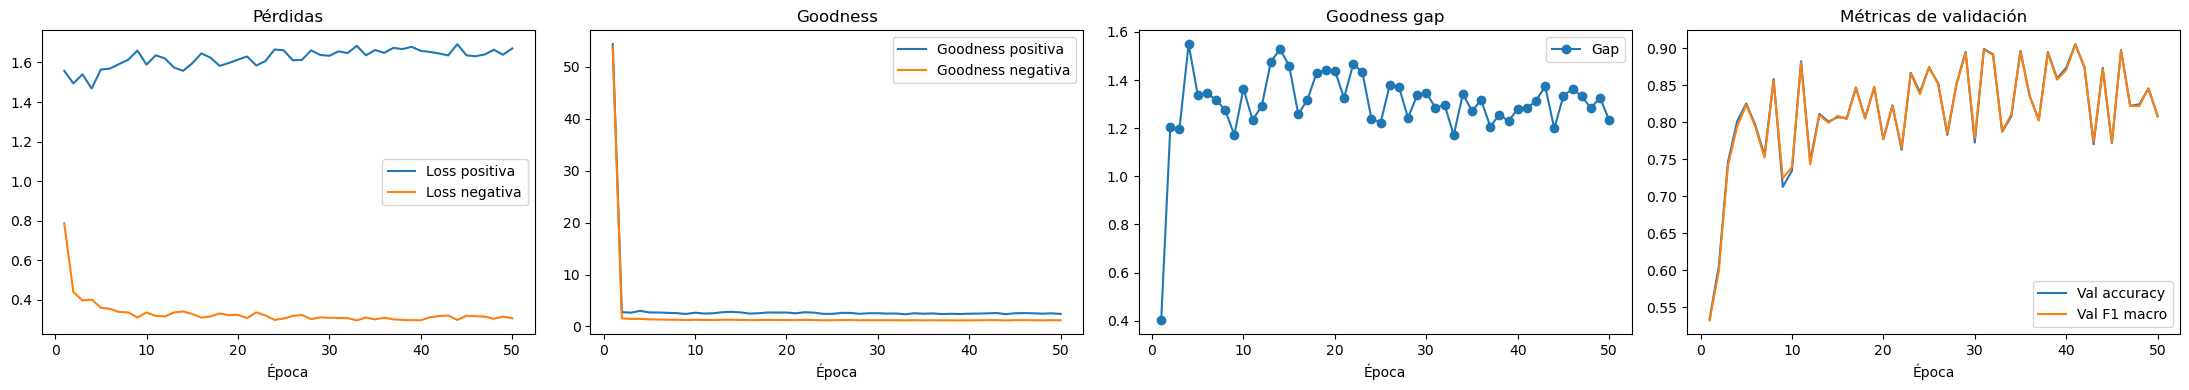

In [44]:
# Este valor puede requerir ajuste.
THRESHOLD = 3.0
# Nueva escala para la etiqueta.
LABEL_SCALE = 3.0

# Entrenar modelo.
model, history = train_ff_model(
    model=model,
    X_train=X_train_proc,
    y_train=y_train,
    X_val=X_val_proc,
    y_val=y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    threshold=THRESHOLD,
    plot_every=1,
    label_scale=LABEL_SCALE,
    weight_clip=WEIGHT_CLIP
)

In [45]:
test_acc, test_f1, y_test_pred = evaluate_ff(
    model,
    X_test_proc,
    y_test,
    label_scale=LABEL_SCALE
)

print("Test accuracy:", round(test_acc, 4))
print("Test F1 macro:", round(test_f1, 4))

Test accuracy: 0.8033
Test F1 macro: 0.8034


In [46]:
# ========================= DEBUG DE SCORES FF =========================
# Este bloque permite observar si el modelo realmente produce
# diferentes scores para cada clase o si todo es casi igual.

# Obtener predicciones sobre algunas muestras de validación
y_pred, scores = predict_ff(model, X_val_proc[:8])

print("Scores de la primera muestra:")
print(scores[0])

print("\nClase predicha:", y_pred[0])

print("\nDiferencia entre máximo y mínimo score:")
print(scores[0].max() - scores[0].min())

Scores de la primera muestra:
[2.8570457 1.9437257 1.761712  1.0893382 2.8776436 4.66183   2.044764
 2.267944  3.2394783 4.219441 ]

Clase predicha: 5

Diferencia entre máximo y mínimo score:
3.5724916


## Evaluación final sobre el conjunto de prueba interna

Como `test.csv` no trae etiquetas, la evaluación supervisada final se hace sobre el subconjunto interno separado desde `train.csv`.

In [47]:
# Evaluar desempeño final en el conjunto de prueba interna.
test_acc, test_f1, y_test_pred = evaluate_ff(model, X_test_proc, y_test)

print("Test accuracy:", round(test_acc, 4))
print("Test F1 macro:", round(test_f1, 4))

Test accuracy: 0.833
Test F1 macro: 0.8316


## Matriz de confusión

Esta visualización permite observar qué clases se confunden con mayor frecuencia.

In [48]:
def plot_confusion(y_true, y_pred):
    """
    Grafica la matriz de confusión.

    Parameters
    ----------
    y_true : np.ndarray
        Etiquetas verdaderas.
    y_pred : np.ndarray
        Etiquetas predichas.
    """
    # Calcular matriz de confusión.
    cm = confusion_matrix(y_true, y_pred)

    # Preparar visualización.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # Dibujar figura.
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Matriz de confusión")
    plt.show()

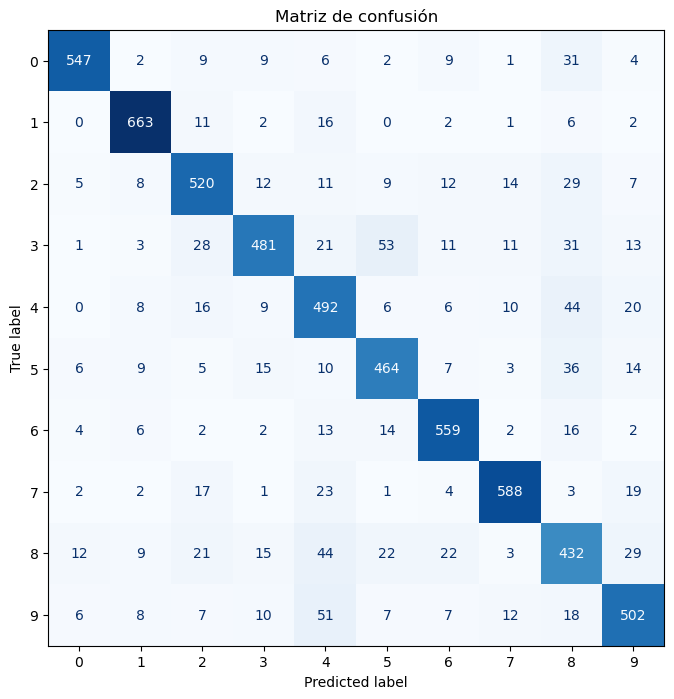

In [49]:
# Mostrar matriz de confusión del conjunto de prueba interna.
plot_confusion(y_test, y_test_pred)

## Ejemplos de predicción

Aquí se muestran imágenes correctamente clasificadas e imágenes mal clasificadas para estudiar el comportamiento del modelo.

In [50]:
def show_predictions(X_flat, y_true, y_pred, img_size, num_samples=10,
                     correct=True):
    """
    Muestra ejemplos correctos o incorrectos.

    Parameters
    ----------
    X_flat : np.ndarray
        Imágenes aplanadas.
    y_true : np.ndarray
        Etiquetas verdaderas.
    y_pred : np.ndarray
        Etiquetas predichas.
    img_size : int
        Resolución de la imagen.
    num_samples : int, optional
        Cantidad de ejemplos a mostrar.
    correct : bool, optional
        Si es True, muestra aciertos. Si es False, errores.
    """
    # Elegir índices según el tipo de resultado deseado.
    if correct:
        indices = np.where(y_true == y_pred)[0]
        title_text = "Predicciones correctas"
    else:
        indices = np.where(y_true != y_pred)[0]
        title_text = "Predicciones incorrectas"

    # Verificar que existan ejemplos.
    if len(indices) == 0:
        print("No hay muestras para mostrar.")
        return

    # Seleccionar subconjunto aleatorio.
    selected = np.random.choice(
        indices,
        min(num_samples, len(indices)),
        replace=False
    )

    # Dibujar imágenes seleccionadas.
    plt.figure(figsize=(14, 3))

    for i, idx in enumerate(selected):
        plt.subplot(1, len(selected), i + 1)
        plt.imshow(X_flat[idx].reshape(img_size, img_size), cmap="gray")
        plt.title(f"T:{y_true[idx]} P:{y_pred[idx]}")
        plt.axis("off")

    plt.suptitle(title_text)
    plt.tight_layout()
    plt.show()

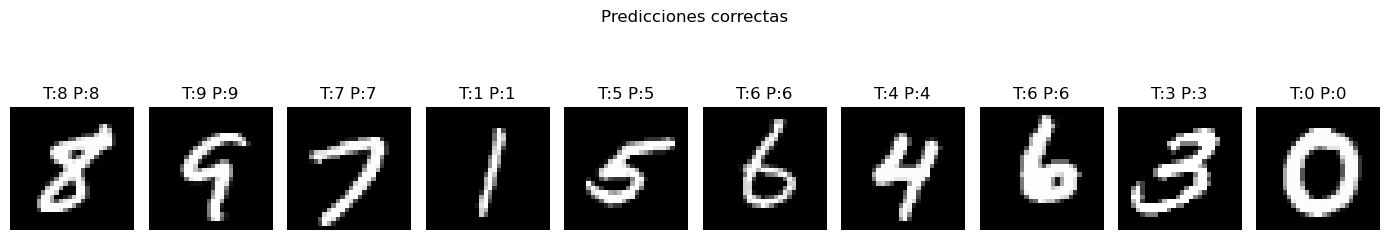

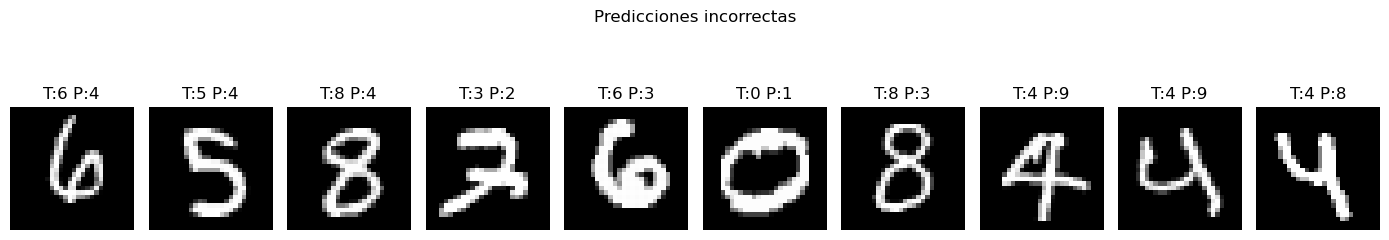

In [51]:
# Mostrar aciertos.
show_predictions(
    X_test_proc,
    y_test,
    y_test_pred,
    img_size=IMG_SIZE,
    num_samples=10,
    correct=True
)

# Mostrar errores.
show_predictions(
    X_test_proc,
    y_test,
    y_test_pred,
    img_size=IMG_SIZE,
    num_samples=10,
    correct=False
)

## Barrido de threshold y label scale

En esta sección se prueban distintas combinaciones de:
- threshold
- label scale

para estudiar su efecto sobre:
- accuracy,
- F1 macro,
- separación positiva-negativa.

Esto permite encontrar una configuración más robusta para el entrenamiento
Forward-Forward.

In [52]:
def run_threshold_labelscale_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    img_size,
    hidden_dims,
    threshold_values,
    label_scale_values,
    epochs=15,
    batch_size=128,
    lr=0.005,
    weight_clip=2.5,
    plot_every=0
):
    """
    Ejecuta un barrido de combinaciones de threshold y label scale.

    Cambios agregados
    -----------------
    1. Permite comparar varias combinaciones de hiperparámetros FF.
    2. Guarda accuracy, F1 y goodness gap final.
    3. Facilita detectar configuraciones con mejor separación entre clases.

    Parameters
    ----------
    X_train : np.ndarray
        Entradas de entrenamiento.
    y_train : np.ndarray
        Etiquetas de entrenamiento.
    X_val : np.ndarray
        Entradas de validación.
    y_val : np.ndarray
        Etiquetas de validación.
    X_test : np.ndarray
        Entradas de prueba.
    y_test : np.ndarray
        Etiquetas de prueba.
    img_size : int
        Tamaño de imagen usado por el modelo.
    hidden_dims : list[int]
        Arquitectura de capas ocultas.
    threshold_values : list[float]
        Lista de thresholds a evaluar.
    label_scale_values : list[float]
        Lista de escalas de etiqueta a evaluar.
    epochs : int, optional
        Número de épocas.
    batch_size : int, optional
        Tamaño del mini-batch.
    lr : float, optional
        Tasa de aprendizaje.
    weight_clip : float, optional
        Límite absoluto para los pesos.
    plot_every : int, optional
        Frecuencia de gráficas durante entrenamiento. Si es 0, no grafica.

    Returns
    -------
    pd.DataFrame
        Tabla con resultados del experimento.
    """
    results = []

    # Recorrer todas las combinaciones.
    for threshold in threshold_values:
        for label_scale in label_scale_values:
            print("=" * 60)
            print(f"Probando threshold={threshold}, label_scale={label_scale}")

            # Inicializar un modelo nuevo para cada combinación.
            input_dim = img_size * img_size + NUM_CLASSES
            model = init_bnn_model(
                input_dim=input_dim,
                hidden_dims=hidden_dims
            )

            # Entrenar el modelo.
            model, history = train_ff_model(
                model=model,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                threshold=threshold,
                plot_every=plot_every if plot_every > 0 else epochs + 1,
                label_scale=label_scale,
                weight_clip=weight_clip
            )

            # Evaluar en validación.
            val_acc, val_f1, _ = evaluate_ff(
                model=model,
                X=X_val,
                y=y_val,
                label_scale=label_scale
            )

            # Evaluar en prueba.
            test_acc, test_f1, _ = evaluate_ff(
                model=model,
                X=X_test,
                y=y_test,
                label_scale=label_scale
            )

            # Obtener goodness gap final.
            final_gap = history["goodness_gap"][-1]

            # Guardar resultado.
            results.append({
                "threshold": threshold,
                "label_scale": label_scale,
                "val_acc": val_acc,
                "val_f1": val_f1,
                "test_acc": test_acc,
                "test_f1": test_f1,
                "goodness_gap_final": final_gap
            })

    return pd.DataFrame(results)

In [53]:
threshold_values = [1.0]
label_scale_values = [1.0]

sweep_results_df = run_threshold_labelscale_experiment(
    X_train=X_train_proc,
    y_train=y_train,
    X_val=X_val_proc,
    y_val=y_val,
    X_test=X_test_proc,
    y_test=y_test,
    img_size=IMG_SIZE,
    hidden_dims=HIDDEN_DIMS,
    threshold_values=threshold_values,
    label_scale_values=label_scale_values,
    epochs=1,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    weight_clip=WEIGHT_CLIP,
    plot_every=0
)

Probando threshold=1.0, label_scale=1.0


In [54]:
# Ordenar por test accuracy descendente.
sweep_results_df = sweep_results_df.sort_values(
    by="test_acc",
    ascending=False
).reset_index(drop=True)

sweep_results_df

,threshold,label_scale,val_acc,val_f1,test_acc,test_f1,goodness_gap_final
0,1.0,1.0,0.315397,0.312665,0.31254,0.310764,0.253582


In [55]:
# Mostrar las 10 mejores combinaciones encontradas.
sweep_results_df.head(15)

,threshold,label_scale,val_acc,val_f1,test_acc,test_f1,goodness_gap_final
0,1.0,1.0,0.315397,0.312665,0.31254,0.310764,0.253582


In [56]:
def plot_threshold_labelscale_results(results_df):
    """
    Grafica resultados del barrido de threshold y label scale.

    Parameters
    ----------
    results_df : pd.DataFrame
        Tabla con resultados del experimento.
    """
    plt.figure(figsize=(10, 5))

    for label_scale in sorted(results_df["label_scale"].unique()):
        subset = results_df[results_df["label_scale"] == label_scale]
        subset = subset.sort_values("threshold")

        plt.plot(
            subset["threshold"],
            subset["test_acc"],
            marker="o",
            label=f"label_scale={label_scale}"
        )

    plt.title("Accuracy de prueba vs threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Test accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

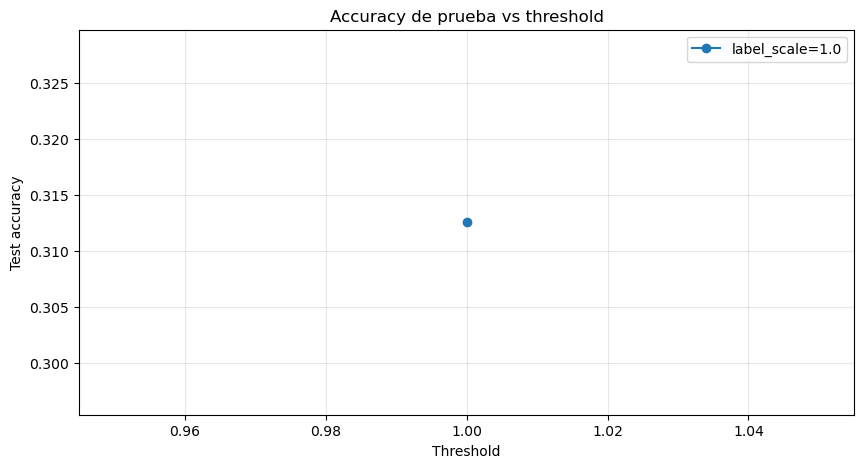

In [57]:
plot_threshold_labelscale_results(sweep_results_df)

## Visualización de predicciones del conjunto test.csv

En esta sección se muestran algunas imágenes del conjunto de prueba junto
con la predicción realizada por el modelo.

Esto permite verificar visualmente si las predicciones parecen razonables.

In [58]:
def visualize_test_predictions(X_test, y_pred, img_size=28, num_samples=20):
    """
    Muestra imágenes del conjunto test junto con la predicción del modelo.

    Cambios agregados
    -----------------
    1. Permite visualizar imágenes sin etiquetas reales.
    2. Muestra la predicción directamente sobre cada imagen.
    3. Facilita validar si el modelo está funcionando correctamente.

    Parameters
    ----------
    X_test : np.ndarray
        Conjunto de imágenes de prueba en formato vectorial.
    y_pred : np.ndarray
        Predicciones generadas por el modelo.
    img_size : int, optional
        Tamaño de la imagen.
    num_samples : int, optional
        Número de imágenes a visualizar.
    """

    # Número de columnas para la visualización.
    cols = 10
    rows = int(np.ceil(num_samples / cols))

    plt.figure(figsize=(cols * 1.5, rows * 1.5))

    for i in range(num_samples):

        plt.subplot(rows, cols, i + 1)

        # Convertir vector a imagen 2D.
        image = X_test[i].reshape(img_size, img_size)

        plt.imshow(image, cmap="gray")

        # Mostrar predicción del modelo.
        plt.title(f"P:{y_pred[i]}", fontsize=10)

        plt.axis("off")

    plt.suptitle("Predicciones del modelo sobre test.csv", fontsize=14)
    plt.tight_layout()
    plt.show()

In [59]:
# Obtener predicciones sobre el conjunto test.csv sin etiquetas.
y_kaggle_pred, kaggle_scores = predict_ff(model, X_kaggle_test_proc)

# Mostrar primeras predicciones.
print("Primeras 20 predicciones:")
print(y_kaggle_pred[:40])

Primeras 20 predicciones:
[2 0 9 9 5 7 0 3 0 3 5 7 4 0 4 5 3 1 9 0 9 1 1 5 7 4 2 7 7 7 7 5 4 2 6 1 9
 5 1 6]


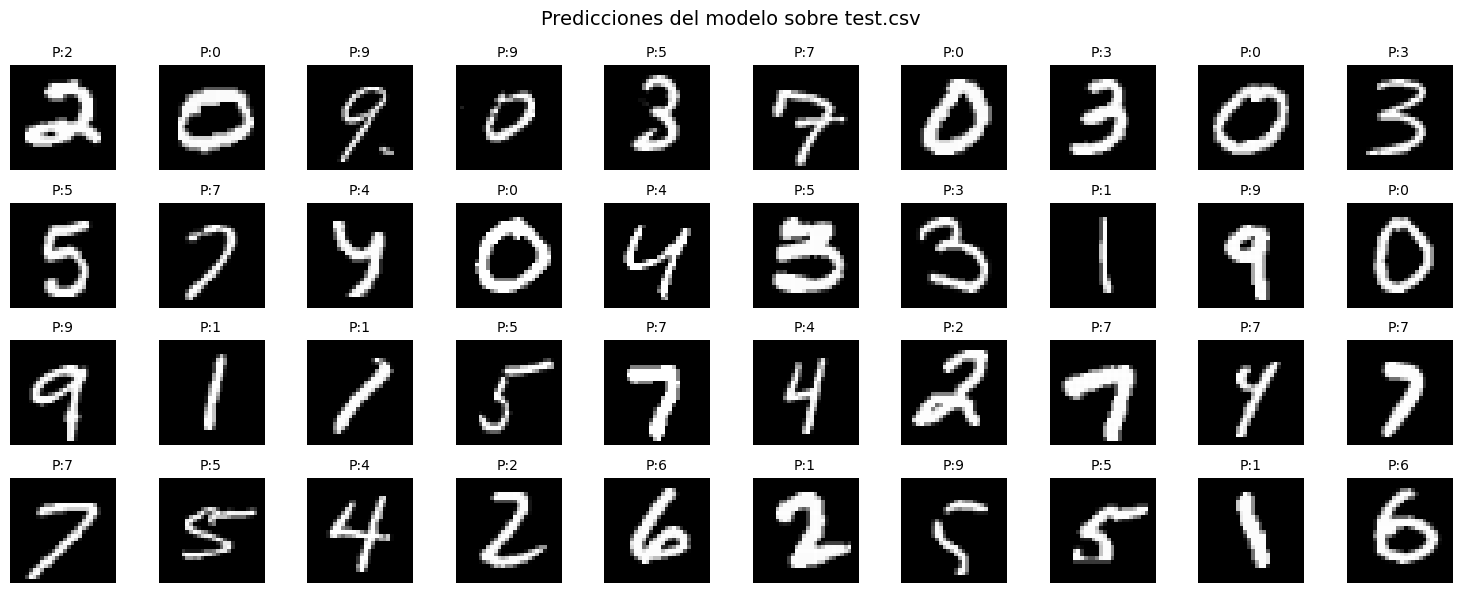

In [60]:
visualize_test_predictions(
    X_test=X_kaggle_test_proc,
    y_pred=y_kaggle_pred,
    img_size=IMG_SIZE,
    num_samples=40
)

## Experimento de sensibilidad a la seed

En esta sección se entrena el mismo modelo varias veces con distintas semillas
aleatorias para analizar la robustez del entrenamiento.

Se comparan:
- accuracy y F1 final,
- goodness gap final,
- curvas de entrenamiento.

El objetivo es observar por qué algunas semillas convergen mejor que otras.

In [69]:
def set_seed(seed):
    """
    Fija la semilla aleatoria de NumPy.

    Parameters
    ----------
    seed : int
        Semilla a utilizar.
    """
    np.random.seed(seed)

In [71]:
def run_single_seed_experiment(
    seed,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    img_size,
    hidden_dims,
    epochs=30,
    batch_size=128,
    lr=0.005,
    threshold=3.0,
    label_scale=3.0,
    weight_clip=2.5
):
    """
    Entrena y evalúa el modelo para una sola seed.

    Parameters
    ----------
    seed : int
        Semilla aleatoria.
    X_train, y_train, X_val, y_val, X_test, y_test : np.ndarray
        Datos ya preprocesados.
    img_size : int
        Tamaño de imagen usado por el modelo.
    hidden_dims : list[int]
        Arquitectura del modelo.
    epochs : int, optional
        Número de épocas.
    batch_size : int, optional
        Tamaño del mini-batch.
    lr : float, optional
        Learning rate.
    threshold : float, optional
        Umbral FF.
    label_scale : float, optional
        Escala de la etiqueta.
    weight_clip : float, optional
        Límite absoluto para pesos.

    Returns
    -------
    result : dict
        Métricas finales e historial de entrenamiento.
    """
    # Fijar semilla.
    set_seed(seed)

    # Inicializar modelo nuevo.
    input_dim = img_size * img_size + NUM_CLASSES
    model = init_bnn_model(
        input_dim=input_dim,
        hidden_dims=hidden_dims
    )

    # Entrenar.
    model, history = train_ff_model(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        threshold=threshold,
        plot_every=epochs + 1,
        label_scale=label_scale,
        weight_clip=weight_clip
    )

    # Evaluar en validación.
    val_acc, val_f1, _ = evaluate_ff(
        model=model,
        X=X_val,
        y=y_val,
        label_scale=label_scale
    )

    # Evaluar en prueba.
    test_acc, test_f1, _ = evaluate_ff(
        model=model,
        X=X_test,
        y=y_test,
        label_scale=label_scale
    )

    # Guardar resultados.
    result = {
        "seed": seed,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "goodness_gap_final": history["goodness_gap"][-1],
        "history": history
    }

    return result

In [72]:
seed_list = [35, 57, 2, 323, 477]

seed_results = []

for seed in seed_list:
    print(f"Ejecutando seed = {seed}")

    result = run_single_seed_experiment(
        seed=seed,
        X_train=X_train_proc,
        y_train=y_train,
        X_val=X_val_proc,
        y_val=y_val,
        X_test=X_test_proc,
        y_test=y_test,
        img_size=IMG_SIZE,
        hidden_dims=HIDDEN_DIMS,
        epochs=30,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        threshold=3.0,
        label_scale=3.0,
        weight_clip=WEIGHT_CLIP
    )

    seed_results.append(result)

Ejecutando seed = 35
Ejecutando seed = 57
Ejecutando seed = 2
Ejecutando seed = 323
Ejecutando seed = 477


In [117]:
seed_summary_df = pd.DataFrame([
    {
        "seed": r["seed"],
        "val_acc": r["val_acc"],
        "val_f1": r["val_f1"],
        "test_acc": r["test_acc"],
        "test_f1": r["test_f1"],
        "goodness_gap_final": r["goodness_gap_final"]
    }
    for r in seed_results
])

seed_summary_df

,seed,val_acc,val_f1,test_acc,test_f1,goodness_gap_final
0,35,0.721111,0.729077,0.715238,0.723961,1.494205
1,57,0.810159,0.807298,0.813651,0.811710,1.407443
2,2,0.817143,0.816152,0.806190,0.805564,1.345019
3,323,0.896349,0.895485,0.890000,0.889444,1.308865
4,477,0.845714,0.845265,0.844286,0.843826,1.479322


In [118]:
mean_test_acc = seed_summary_df["test_acc"].mean()
std_test_acc = seed_summary_df["test_acc"].std()

mean_test_f1 = seed_summary_df["test_f1"].mean()
std_test_f1 = seed_summary_df["test_f1"].std()

print(f"Test accuracy medio: {mean_test_acc:.4f}")
print(f"Desviación estándar accuracy: {std_test_acc:.4f}")
print(f"Test F1 medio: {mean_test_f1:.4f}")
print(f"Desviación estándar F1: {std_test_f1:.4f}")

Test accuracy medio: 0.8139
Desviación estándar accuracy: 0.0642
Test F1 medio: 0.8149
Desviación estándar F1: 0.0607


In [119]:
def plot_seed_histories(seed_results):
    """
    Compara las curvas de entrenamiento entre distintas seeds.

    Parameters
    ----------
    seed_results : list[dict]
        Lista de resultados con historial.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for result in seed_results:
        seed = result["seed"]
        history = result["history"]

        axes[0].plot(
            history["epoch"],
            history["goodness_gap"],
            label=f"seed={seed}"
        )

        axes[1].plot(
            history["epoch"],
            history["val_acc"],
            label=f"seed={seed}"
        )

        axes[2].plot(
            history["epoch"],
            history["train_goodness_pos"],
            linestyle="--",
            alpha=0.8
        )
        axes[2].plot(
            history["epoch"],
            history["train_goodness_neg"],
            alpha=0.8
        )

    axes[0].set_title("Goodness gap por seed")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Gap")
    axes[0].legend()

    axes[1].set_title("Validation accuracy por seed")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    axes[2].set_title("Goodness positiva y negativa")
    axes[2].set_xlabel("Época")
    axes[2].set_ylabel("Goodness")

    plt.tight_layout()
    plt.show()

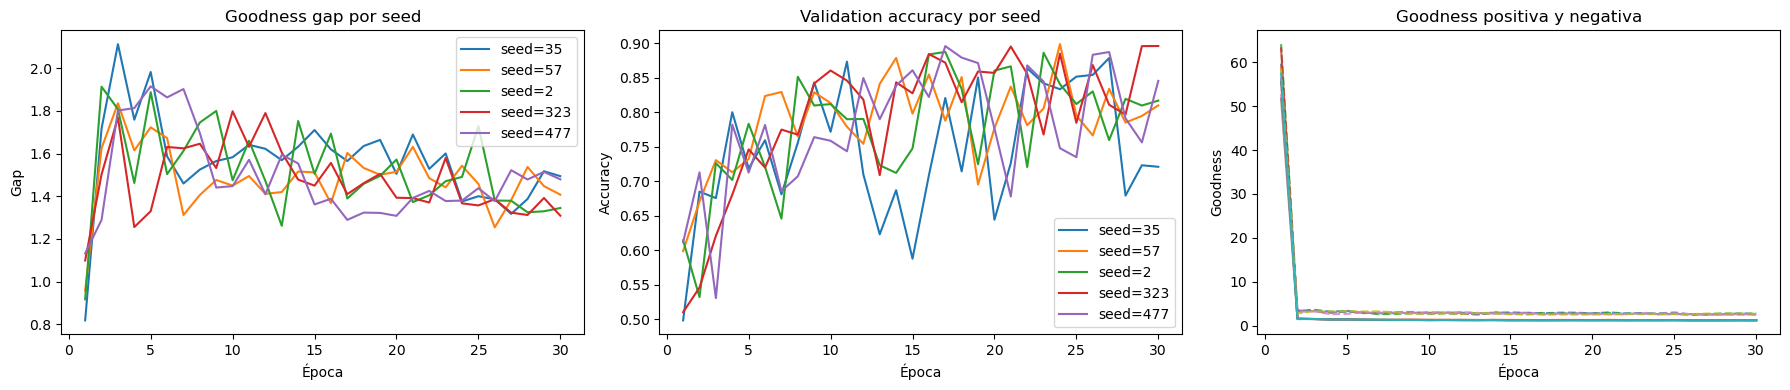

In [120]:
plot_seed_histories(seed_results)

In [121]:
best_idx = seed_summary_df["test_acc"].idxmax()
worst_idx = seed_summary_df["test_acc"].idxmin()

best_seed = int(seed_summary_df.loc[best_idx, "seed"])
worst_seed = int(seed_summary_df.loc[worst_idx, "seed"])

print(f"Mejor seed: {best_seed}")
print(f"Peor seed: {worst_seed}")

Mejor seed: 323
Peor seed: 35


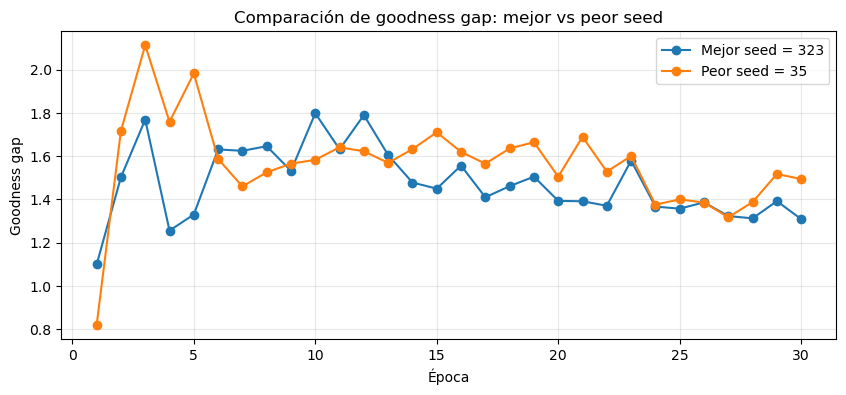

In [122]:
best_result = next(r for r in seed_results if r["seed"] == best_seed)
worst_result = next(r for r in seed_results if r["seed"] == worst_seed)

plt.figure(figsize=(10, 4))

plt.plot(
    best_result["history"]["epoch"],
    best_result["history"]["goodness_gap"],
    marker="o",
    label=f"Mejor seed = {best_seed}"
)

plt.plot(
    worst_result["history"]["epoch"],
    worst_result["history"]["goodness_gap"],
    marker="o",
    label=f"Peor seed = {worst_seed}"
)

plt.title("Comparación de goodness gap: mejor vs peor seed")
plt.xlabel("Época")
plt.ylabel("Goodness gap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

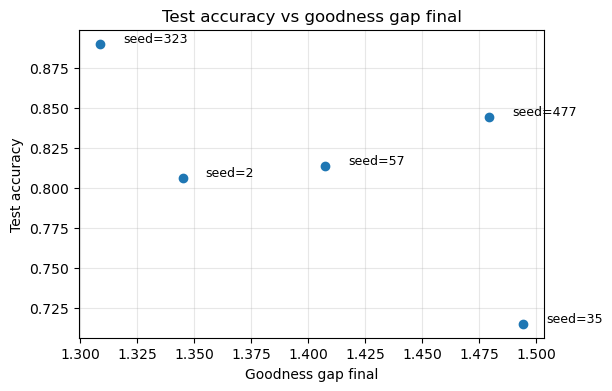

In [123]:
plt.figure(figsize=(6, 4))
plt.scatter(
    seed_summary_df["goodness_gap_final"],
    seed_summary_df["test_acc"]
)

for _, row in seed_summary_df.iterrows():
    plt.text(
        row["goodness_gap_final"] + 0.01,
        row["test_acc"] + 0.001,
        f"seed={int(row['seed'])}",
        fontsize=9
    )

plt.title("Test accuracy vs goodness gap final")
plt.xlabel("Goodness gap final")
plt.ylabel("Test accuracy")
plt.grid(True, alpha=0.3)
plt.show()